In [1]:
cpu_usage = [
    23.5, 25.1, 24.8, 26.3, 22.9, 24.0, 25.7, 23.2, 24.6, 26.1,
    25.4, 24.3, 23.8, 71.2, 88.5, 92.3, 85.7, 45.2, 27.9, 25.3,
    24.1, 26.8, 25.5, 23.7, 24.9, 22.4, 25.8, 24.2, 26.5, 25.0,
]

In [2]:
# Suggested alpha for initial setup.
# High value (0.8) -> value follows closely the data. Can be noisy.
# Low value (0.1) -> value too smooth. Doesn't react quickly.
ALPHA = 2 / (len(cpu_usage) + 1)
ANOMALY_THRESHOLD = 3

Alpha:  0.06451612903225806


In [8]:
# formula: new_average = alpha * current_value + (1 - alpha) * previous_average
# We start with the first value of the list. Could also use the average of the first few values.

emwa = cpu_usage[0]
calculated_emwa = []
values = cpu_usage[1:]

calculated_emwa.append((emwa, cpu_usage[0]))
for cpu in values:
    emwa = ALPHA * cpu + (1 - ALPHA) * emwa
    is_anomaly = cpu > ANOMALY_THRESHOLD * emwa
    if is_anomaly:
        continue
    calculated_emwa.append((cpu, emwa))

In [4]:
import matplotlib.pyplot as plt

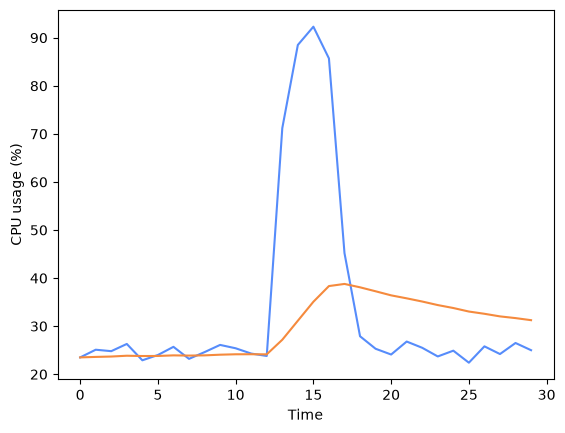

In [9]:

plt.plot(cpu_usage)
plt.plot([emwa[1] for emwa in calculated_emwa])
plt.ylabel('CPU usage (%)')
plt.xlabel('Time')
plt.show()